### Quantifying the correlation between cell counts and the robustness/infidelity of spatial statistics

In [33]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

#### Get cell count data for all samples (can use across spatial statistics)

In [24]:
# Get cell count data
data = os.listdir('/home/ecdyer/labshare/PROJECTS/SPATIAL_STATS/data/P2_BTC')
# 1 = tumor, 0 = immune

sample_data_counts = {}
for sample in data:
    sample_path = os.path.join('/home/ecdyer/labshare/PROJECTS/SPATIAL_STATS/data/P2_BTC', sample)
    sample_data = pd.read_csv(sample_path)
    sample = sample.replace('.csv', '')
    sample_data_counts[sample] = sample_data['tumor_immune'].value_counts()

    # Create dictionary of immune:tumor ratios
    sample_data_ratios = {}
    for sample, counts in sample_data_counts.items():
        # Get counts of immune (0) and tumor (1) cells
        immune_count = counts.get(0, 0)  # Default to 0 if no immune cells
        tumor_count = counts.get(1, 0)   # Default to 0 if no tumor cells
        # Calculate ratio, handling division by zero
        ratio = immune_count / tumor_count if tumor_count > 0 else float('inf')
        sample_data_ratios[sample] = round(ratio, 4)

print(sample_data_ratios)

{'S6_L2': np.float64(0.1729), 'S3_L2': np.float64(0.1682), 'S5_L2': np.float64(0.1663), 'S1': np.float64(0.0702), 'S3_L1': np.float64(0.0474), 'S4_L2': np.float64(0.0107), 'S6_L1': np.float64(0.005), 'S5 L3': np.float64(0.2176), 'S2': np.float64(1.1736), 'S5_L1': np.float64(0.2073), 'S4_L1': np.float64(0.0372)}


#### TCM Analysis

In [67]:
# TCM
# 1. Get the infidelity of the TCM
# 2. Get the cell count ratio
# 3. Plot the correlation between the two

tcm_infidelity = pd.read_csv('/home/ecdyer/labshare/PROJECTS/SPATIAL_STATS/tcm_results/infidelity_results.csv')
# Get list of simulation columns (excluding 'sample_name' and unnamed index column)
simulation_cols = [col for col in tcm_infidelity.columns if col not in ['sample_name', 'Unnamed: 0']]

# Create empty lists to store data
sample_names = []
sim_types = []
infidelity_values = []
ratio_values = []
# Iterate through each sample and simulation type
for _, row in tcm_infidelity.iterrows():
    sample_name = row['sample_name'].strip()  # Remove any whitespace
    
    # Get the ratio for this sample if it exists
    ratio = sample_data_ratios.get(sample_name)
    
    if ratio is not None:
        # Add entry for each simulation type
        for sim_type in simulation_cols:
            sample_names.append(sample_name)
            sim_types.append(sim_type)
            infidelity_values.append(row[sim_type])
            ratio_values.append(ratio)

# Create DataFrame
infidelity_data = pd.DataFrame({
    'sample_name': sample_names,
    'sim_type': sim_types, 
    'infidelity': infidelity_values,
    'ratio': ratio_values
})

print("Combined DataFrame created with", len(infidelity_data), "entries")
print(infidelity_data.head())

Combined DataFrame created with 77 entries
  sample_name                       sim_type  infidelity   ratio
0       S4_L1                 raw_simulation    0.144432  0.0372
1       S4_L1       high_immune_infiltration    0.017841  0.0372
2       S4_L1               immune_exclusion    0.012727  0.0372
3       S4_L1          immune_ring_formation    0.011943  0.0372
4       S4_L1  scattered_immune_surveillance    0.014048  0.0372


In [68]:
tcm_max_sens = pd.read_csv('/home/ecdyer/labshare/PROJECTS/SPATIAL_STATS/tcm_results/max_sens_results.csv')
# Get list of simulation columns (excluding 'sample_name' and unnamed index column)
simulation_cols = [col for col in tcm_max_sens.columns if col not in ['sample_name', 'Unnamed: 0']]

# Create empty lists to store data
sample_names = []
sim_types = []
max_sens_values = []
ratio_values = []
# Iterate through each sample and simulation type
for _, row in tcm_max_sens.iterrows():
    sample_name = row['sample_name'].strip()  # Remove any whitespace
    
    # Get the ratio for this sample if it exists
    ratio = sample_data_ratios.get(sample_name)
    
    if ratio is not None:
        # Add entry for each simulation type
        for sim_type in simulation_cols:
            sample_names.append(sample_name)
            sim_types.append(sim_type)
            max_sens_values.append(row[sim_type])
            ratio_values.append(ratio)

# Create DataFrame
max_sens_data = pd.DataFrame({
    'sample_name': sample_names,
    'sim_type': sim_types, 
    'max_sens': max_sens_values,
    'ratio': ratio_values
})

print("Combined DataFrame created with", len(max_sens_data), "entries")
print(max_sens_data.head())

Combined DataFrame created with 77 entries
  sample_name                       sim_type  max_sens   ratio
0       S4_L1                 raw_simulation  0.021603  0.0372
1       S4_L1       high_immune_infiltration  0.009223  0.0372
2       S4_L1               immune_exclusion  0.007073  0.0372
3       S4_L1          immune_ring_formation  0.008573  0.0372
4       S4_L1  scattered_immune_surveillance  0.009521  0.0372


In [64]:
def plot_correlation(data, 
                     data_col_name, 
                     sample_col_name, 
                     x_label, 
                     y_label, 
                     title, 
                     output_path=None, 
                     figsize=(10, 6), 
                     legend_loc='upper left',
                     legend_size=10,
                     dpi=300,
                     show_plot=True):

    # Set seaborn style
    sns.set_style("darkgrid")

    # Create scatter plot
    plt.figure(figsize=figsize)

    # Get unique samples for color mapping
    unique_samples = data[sample_col_name].unique()
    colors = plt.cm.tab20(np.linspace(0, 1, len(unique_samples)))
    color_dict = dict(zip(unique_samples, colors))

    # Calculate statistics to identify outliers
    values = data[data_col_name].values.astype(np.float64)
    ratio_values = data['ratio'].values

    # Calculate Q1, Q3 and IQR for both metrics
    q1_sens, q3_sens = np.percentile(values, [25, 75])
    q1_ratio, q3_ratio = np.percentile(ratio_values, [25, 75])
    iqr_sens = q3_sens - q1_sens
    iqr_ratio = q3_ratio - q1_ratio

    # Define bounds (1.5 * IQR method)
    sens_lower = q1_sens - 1.5 * iqr_sens
    sens_upper = q3_sens + 1.5 * iqr_sens
    ratio_lower = q1_ratio - 1.5 * iqr_ratio
    ratio_upper = q3_ratio + 1.5 * iqr_ratio

    # Lists to store non-outlier points for regression
    x_values = []
    y_values = []

    # Plot each point, excluding outliers
    for _, row in data.iterrows():
        ratio = row['ratio']
        explainer = row[data_col_name]
        sample_name = row[sample_col_name]

        # Skip outliers
        if (explainer < sens_lower or explainer > sens_upper or 
            ratio < ratio_lower or ratio > ratio_upper):
            continue

        # Store values for regression
        x_values.append(ratio)
        y_values.append(explainer)

        # Plot point
        plt.scatter(ratio, explainer,
                   color=color_dict[sample_name],
                   label=sample_name,
                   alpha=1)

    # Calculate regression line
    slope, intercept, r_value, p_value, std_err = stats.linregress(x_values, y_values)
    line = slope * np.array(x_values) + intercept

    # Format p-value
    if p_value > 0.001:
        p_value_str = f'{p_value:.3f}'
    else:
        p_value_str = f'{p_value:.3e}'

    # Plot regression line
    plt.plot(x_values, line, 'r', label=f'Regression line\nr={r_value:.3f}, p={p_value_str}')

    # Set axis limits slightly beyond the non-outlier bounds
    plt.ylim(0, max(y_values) * 1.1)
    plt.xlim(0, max(x_values) * 1.1)

    plt.ylabel(y_label)
    plt.xlabel(x_label)
    plt.title(title)

    # Handle legend with unique entries only
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys(), loc=legend_loc, fontsize=legend_size)

    plt.tight_layout()
    if output_path is not None:
        plt.savefig(output_path, dpi=dpi)
    if show_plot is True:
        plt.show()


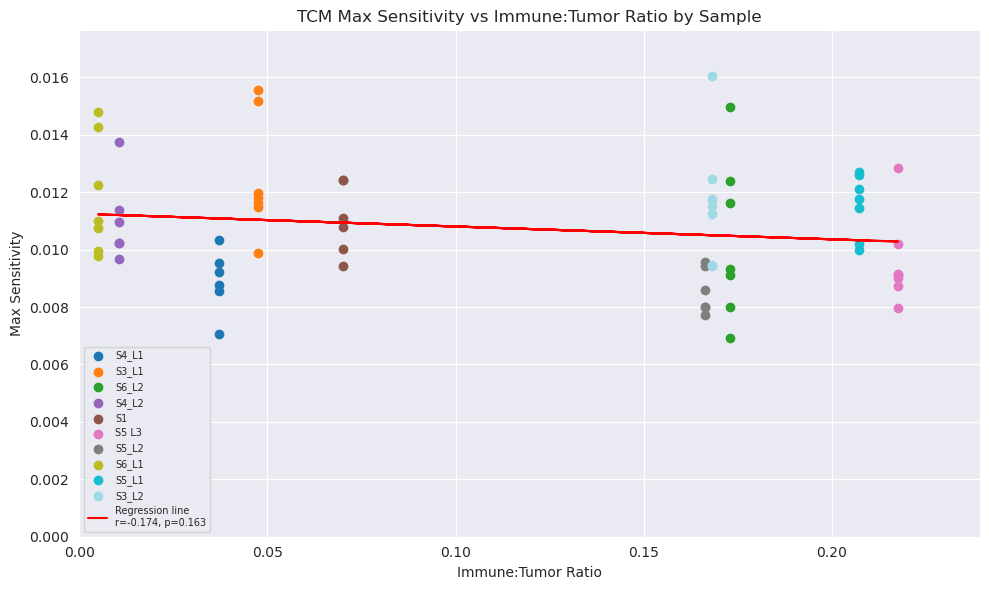

In [69]:
# Plot TCM Max Sensitivity vs Immune:Tumor Ratio
plot_correlation(
    data=max_sens_data,
    data_col_name='max_sens',
    sample_col_name='sample_name',
    x_label='Immune:Tumor Ratio',
    legend_loc='lower left',
    legend_size=7,
    y_label='Max Sensitivity',
    title='TCM Max Sensitivity vs Immune:Tumor Ratio by Sample',
    show_plot=True,
    output_path='/home/ecdyer/labshare/PROJECTS/SPATIAL_STATS/figures/regression_plots/tcm_max_sens_vs_ratio.png'
)

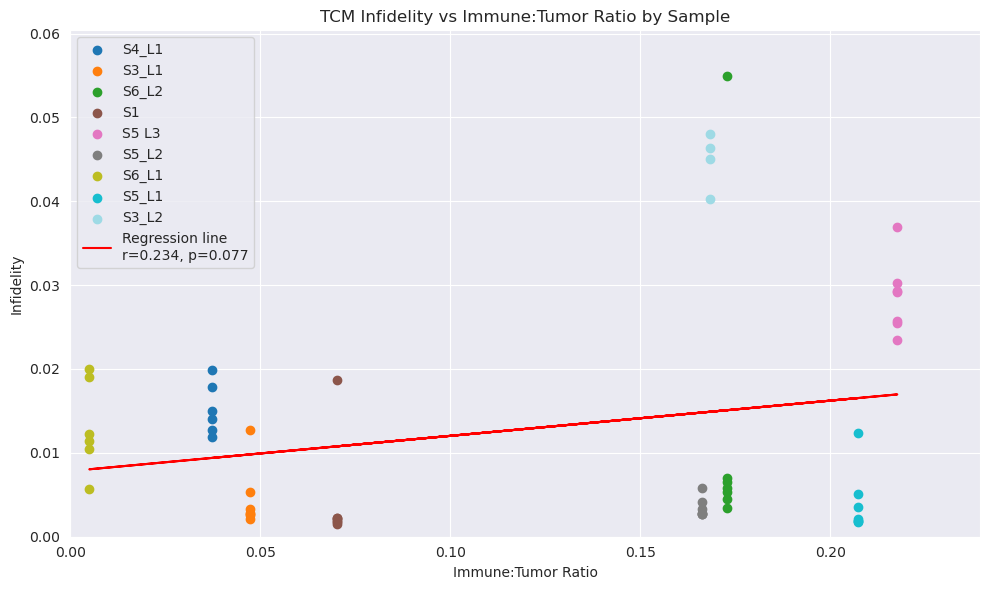

In [70]:
# Plot TCM Infidelity vs Immune:Tumor Ratio
plot_correlation(
    data=infidelity_data,
    data_col_name='infidelity',
    sample_col_name='sample_name',
    x_label='Immune:Tumor Ratio',
    y_label='Infidelity',
    title='TCM Infidelity vs Immune:Tumor Ratio by Sample',
    show_plot=True
)


#### GD Analysis

In [71]:
# Add sample ratio column to GD results

gd_tcm_results = '/home/ecdyer/labshare/PROJECTS/SPATIAL_STATS/gd_results/gd_max_sens_results.csv'
gd_tcm_results = pd.read_csv(gd_tcm_results, index_col=0)
gd_tcm_results['ratio'] = gd_tcm_results['sample_name'].map(sample_data_ratios)

gd_infidelity_results = '/home/ecdyer/labshare/PROJECTS/SPATIAL_STATS/gd_results/gd_infidelity_results.csv'
gd_infidelity_results = pd.read_csv(gd_infidelity_results, index_col=0)
gd_infidelity_results['ratio'] = gd_infidelity_results['sample_name'].map(sample_data_ratios)

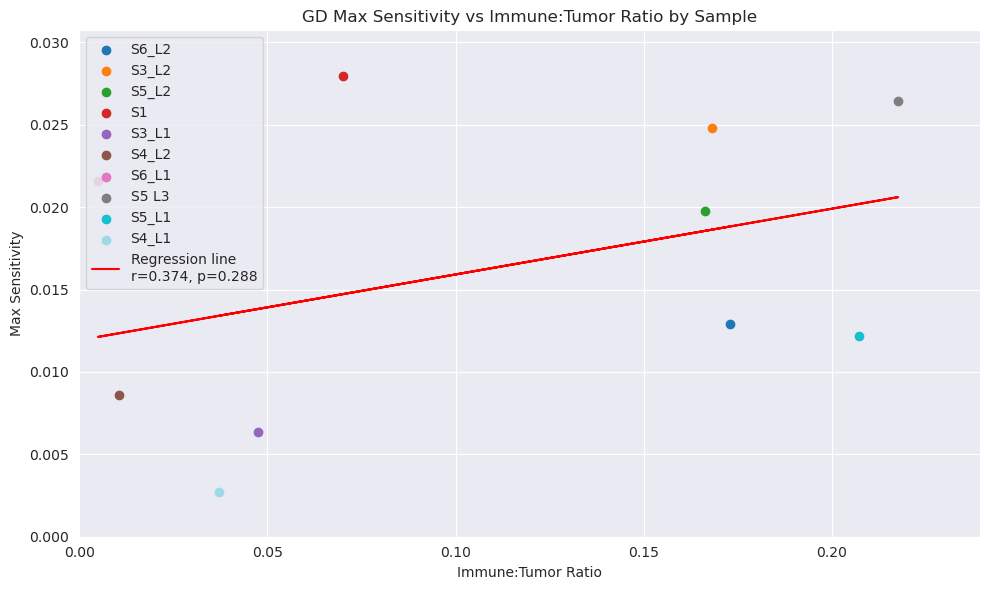

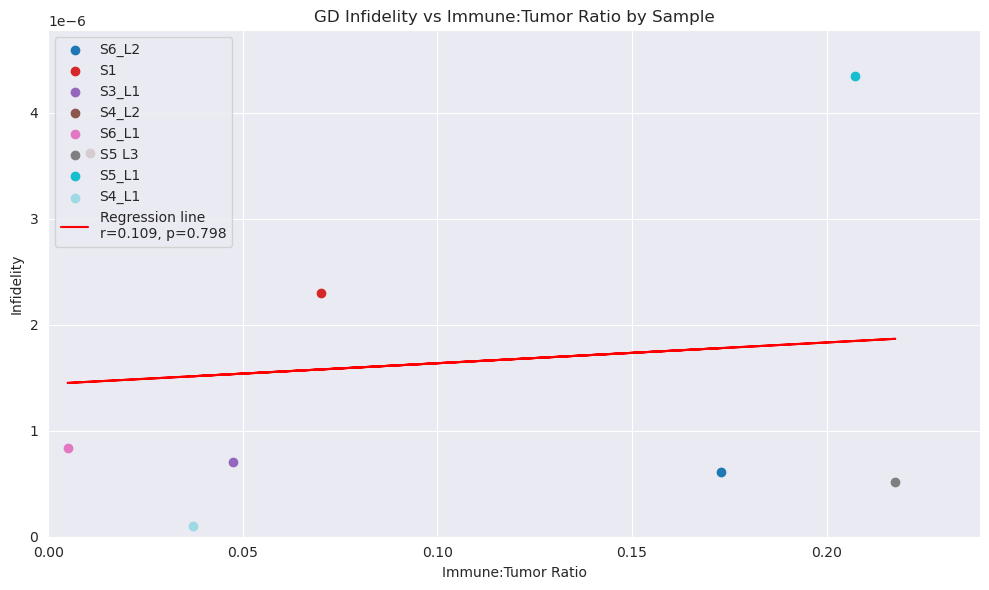

In [72]:
# Plot GD Max Sensitivity vs Immune:Tumor Ratio
plot_correlation(
    data=gd_tcm_results,
    data_col_name='max_sens',
    sample_col_name='sample_name',
    x_label='Immune:Tumor Ratio',
    y_label='Max Sensitivity',
    title='GD Max Sensitivity vs Immune:Tumor Ratio by Sample',
    show_plot=True,
    output_path='/home/ecdyer/labshare/PROJECTS/SPATIAL_STATS/figures/regression_plots/gd_max_sens_vs_ratio.png'
)
# Plot GD Infidelity vs Immune:Tumor Ratio
plot_correlation(
    data=gd_infidelity_results,
    data_col_name='infidelity',
    sample_col_name='sample_name',
    x_label='Immune:Tumor Ratio',
    y_label='Infidelity',
    title='GD Infidelity vs Immune:Tumor Ratio by Sample',
    show_plot=True,
    output_path='/home/ecdyer/labshare/PROJECTS/SPATIAL_STATS/figures/regression_plots/gd_infidelity_vs_ratio.png'
)


#### J-Function Analysis

In [59]:
# Add sample ratio column to J-Function results

j_function_infidelity_results = '/home/ecdyer/labshare/PROJECTS/SPATIAL_STATS/j_function_results/infidelity_results_cleaned.csv'
j_function_infidelity_results = pd.read_csv(j_function_infidelity_results)
j_function_infidelity_results['ratio'] = j_function_infidelity_results['sample_name'].map(sample_data_ratios)

j_function_max_sens_results = '/home/ecdyer/labshare/PROJECTS/SPATIAL_STATS/j_function_results/max_sens_results_cleaned.csv'
j_function_max_sens_results = pd.read_csv(j_function_max_sens_results)
j_function_max_sens_results['ratio'] = j_function_max_sens_results['sample_name'].map(sample_data_ratios)

In [60]:
# Create dataframes for max sens and infidelity

# Get list of simulation columns (excluding 'sample_name', 'ratio' and unnamed index column)
simulation_cols = [col for col in j_function_infidelity_results.columns if col not in ['sample_name', 'Unnamed: 0', 'ratio']]

# Create empty lists to store data
sample_names = []
sim_types = []
infidelity_values = []
ratio_values = []
# Iterate through each sample and simulation type
for _, row in j_function_infidelity_results.iterrows():
    sample_name = row['sample_name'].strip()  # Remove any whitespace
    
    # Get the ratio for this sample if it exists
    ratio = sample_data_ratios.get(sample_name)
    
    if ratio is not None:
        # Add entry for each simulation type
        for sim_type in simulation_cols:
            sample_names.append(sample_name)
            sim_types.append(sim_type)
            infidelity_values.append(row[sim_type])
            ratio_values.append(ratio)

# Create DataFrame
infidelity_data = pd.DataFrame({
    'sample_name': sample_names,
    'sim_type': sim_types, 
    'infidelity': infidelity_values,
    'ratio': ratio_values
})

print("Combined DataFrame created with", len(infidelity_data), "entries")
print(infidelity_data.head())

Combined DataFrame created with 77 entries
  sample_name                       sim_type    infidelity   ratio
0       S4_L1                 raw_simulation  7.358770e+17  0.0372
1       S4_L1       high_immune_infiltration  6.129874e+19  0.0372
2       S4_L1               immune_exclusion  1.084704e+20  0.0372
3       S4_L1          immune_ring_formation  2.331700e+19  0.0372
4       S4_L1  scattered_immune_surveillance  8.125276e+19  0.0372


In [61]:
# Create dataframes for max sens and infidelity

# Get list of simulation columns (excluding 'sample_name', 'ratio' and unnamed index column)
simulation_cols = [col for col in j_function_max_sens_results.columns if col not in ['sample_name', 'Unnamed: 0', 'ratio']]

# Create empty lists to store data
sample_names = []
sim_types = []
max_sens_values = []
ratio_values = []
# Iterate through each sample and simulation type
for _, row in j_function_max_sens_results.iterrows():
    sample_name = row['sample_name'].strip()  # Remove any whitespace
    
    # Get the ratio for this sample if it exists
    ratio = sample_data_ratios.get(sample_name)
    
    if ratio is not None:
        # Add entry for each simulation type
        for sim_type in simulation_cols:
            sample_names.append(sample_name)
            sim_types.append(sim_type)
            max_sens_values.append(row[sim_type])
            ratio_values.append(ratio)

# Create DataFrame
max_sens_data = pd.DataFrame({
    'sample_name': sample_names,
    'sim_type': sim_types, 
    'max_sens': max_sens_values,
    'ratio': ratio_values
})

print("Combined DataFrame created with", len(max_sens_data), "entries")
print(max_sens_data.head())

Combined DataFrame created with 77 entries
  sample_name                       sim_type  max_sens   ratio
0       S4_L1                 raw_simulation  1.225250  0.0372
1       S4_L1       high_immune_infiltration  1.003412  0.0372
2       S4_L1               immune_exclusion  2.735705  0.0372
3       S4_L1          immune_ring_formation  4.086769  0.0372
4       S4_L1  scattered_immune_surveillance  2.892362  0.0372


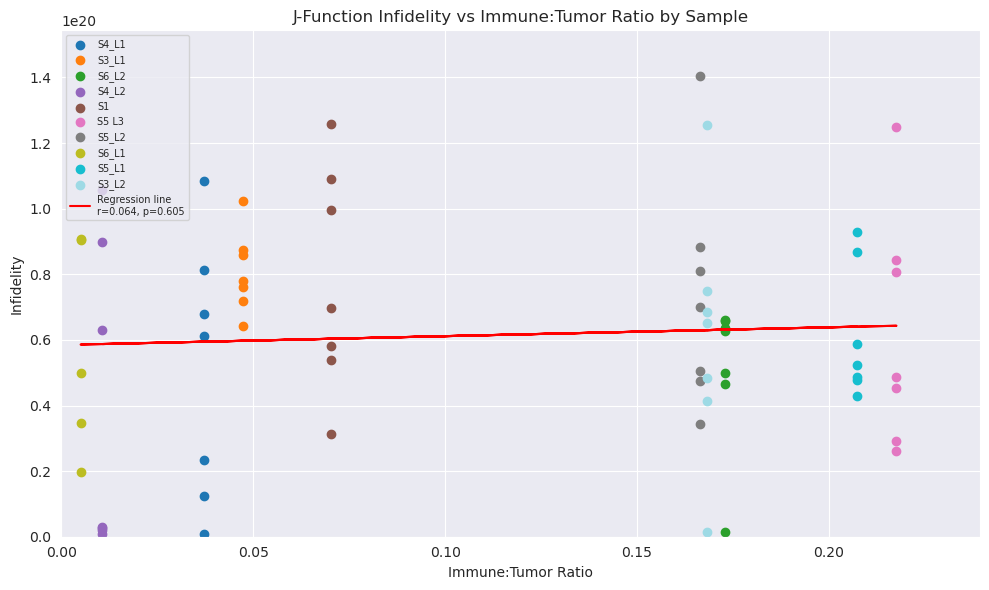

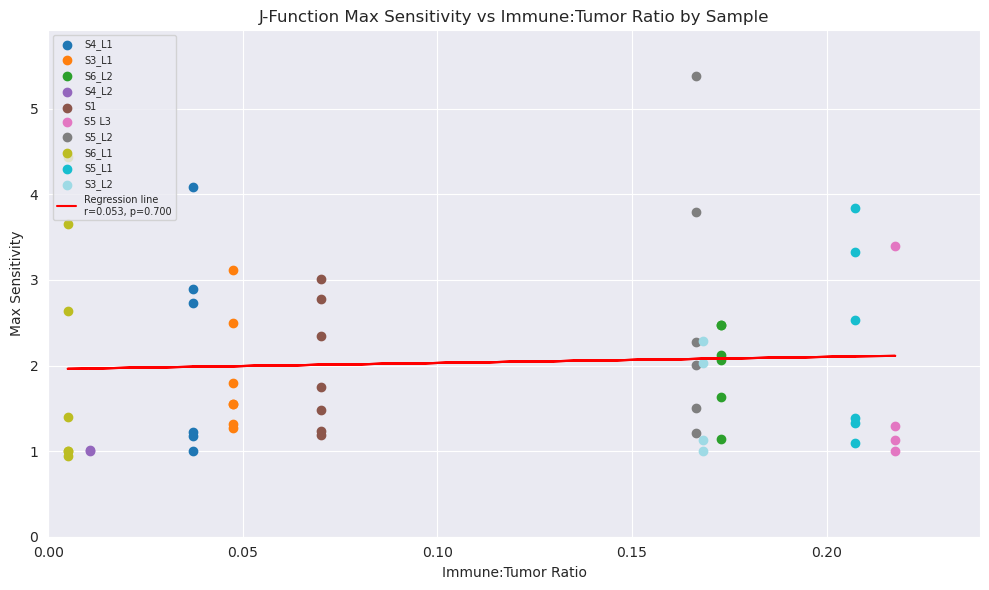

In [66]:
# Plot J-Function Infidelity vs Immune:Tumor Ratio
plot_correlation(
    data=infidelity_data,
    data_col_name='infidelity',
    sample_col_name='sample_name',
    x_label='Immune:Tumor Ratio',
    y_label='Infidelity',
    title='J-Function Infidelity vs Immune:Tumor Ratio by Sample',
    show_plot=True,
    legend_size=7,
    output_path='/home/ecdyer/labshare/PROJECTS/SPATIAL_STATS/figures/regression_plots/j_function_infidelity_vs_ratio.png'
)

# Plot J-Function Max Sensitivity vs Immune:Tumor Ratio
plot_correlation(
    data=max_sens_data,
    data_col_name='max_sens',
    sample_col_name='sample_name',
    x_label='Immune:Tumor Ratio',
    y_label='Max Sensitivity',
    title='J-Function Max Sensitivity vs Immune:Tumor Ratio by Sample',
    show_plot=True,
    legend_size=7,
    output_path='/home/ecdyer/labshare/PROJECTS/SPATIAL_STATS/figures/regression_plots/j_function_max_sens_vs_ratio.png'
)